# Minimal EV SoC and home-charging prototype on NHTS vehicle days

**Pipeline:** observed/derived NHTS trip chain → assumed driving energy →
battery energy/SoC → eligible Home parking → assumed grid charging →
15-minute individual and sample-aggregate demand.

Source data are the *interim* exports from `03_trip_chains.ipynb`, documented in
`docs/methodology/vehicle_trip_chain_schema.md`. This notebook does not modify
those exports. The observed-window scenario uses only reconstructed internal
Home gaps. A separate synthetic scenario assumes terminal Home parking until
the same vehicle-day's first departure clock time the following day. The public
NHTS survey day is 04:00–04:00; `TDAYDATE` is YYYYMM, not an exact date. EV
specifications, initial state, and charging decisions are synthetic assumptions.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Markdown

root = Path.cwd().resolve()
if not (root / "data" / "interim" / "vehicle_trip_chains.csv").exists():
    root = root.parent
sys.path.insert(0, str(root))
from src.charging.simple_ev import (
    EVParameters, simulate_vehicle, reconstruct_terminal_home_charge, MILES_TO_KM,
    DAY_START_MIN, DAY_END_MIN, BIN_MIN, BIN_STARTS_MIN, SOC_TIMES_MIN,
)

interim = root / "data" / "interim"
figure_dir = root / "outputs" / "figures" / "ev_load_prototype"
figure_dir.mkdir(parents=True, exist_ok=True)
id_types = {"HOUSEID":"string", "VEHCASEID":"string", "TDCASEID":"string",
            "next_TDCASEID":"string"}
legs = pd.read_csv(interim / "vehicle_trip_chains.csv", dtype=id_types, low_memory=False)
gaps = pd.read_csv(interim / "vehicle_parking_intervals.csv", dtype=id_types, low_memory=False)

display(pd.DataFrame({
    "Interim file":["vehicle_trip_chains.csv","vehicle_parking_intervals.csv"],
    "Rows":[len(legs),len(gaps)], "Columns":[legs.shape[1],gaps.shape[1]],
    "Grain":["candidate driver leg","consecutive-leg gap"],
}))
display(pd.DataFrame({"Leg fields":pd.Series(legs.columns),
                      "Parking fields":pd.Series(gaps.columns)}))
required_leg = {"VEHCASEID","TDCASEID","vehicle_leg_index","survey_start_min",
                "survey_end_min","trip_distance_miles","origin_group",
                "destination_group","chain_status","begins_home","ends_home"}
required_gap = {"VEHCASEID","TDCASEID","next_TDCASEID","parking_start_min",
                "parking_end_min","destination_group","analysis_eligible"}
assert required_leg.issubset(legs.columns) and required_gap.issubset(gaps.columns)
assert legs.TDCASEID.is_unique



,Interim file,Rows,Columns,Grain
0,vehicle_trip_chains.csv,19673,30,candidate driver leg
1,vehicle_parking_intervals.csv,12799,22,consecutive-leg gap


,Leg fields,Parking fields
0,HOUSEID,HOUSEID
1,VEHCASEID,VEHCASEID
2,VEHID,TDCASEID
3,PERSONID,next_TDCASEID
4,TDCASEID,PERSONID
5,SEQ_TRIPID,next_PERSONID
6,TRAVDAY,WHYTO
7,TDAYDATE,next_WHYFROM
8,vehicle_leg_index,destination_group
9,STRTTIME,parking_start_min


## 1. Analysis population and source-to-model boundary

One row of `legs` is a **candidate NHTS person-reported driver leg**, not a
proven independent vehicle movement. Notebook 03 held out simultaneous and
overlapping vehicle-days. Here we retain multi-leg `chain_status=complete`
vehicles with all trips inside 04:00–04:00 and one `analysis_eligible` internal
gap per consecutive pair. These are the same purpose-consistent gap flags used
by notebook 03. The exact ID/time joins are rechecked inside the simulator.

`trip_distance_miles` and survey clock coordinates come from NHTS/its trip-chain
processing. Miles→km, trip energy, SoC, and power are newly **derived** using
synthetic EV parameters. The NHTS trip weight is not applied to constructed
vehicle charging events. The aggregate is a sample simulation, not a forecast.

In [2]:
vehicle = legs.groupby("VEHCASEID").agg(
    n_legs=("TDCASEID","size"), chain_status=("chain_status","first"),
    first_start=("survey_start_min","min"), last_end=("survey_end_min","max"),
    daily_miles=("trip_distance_miles","sum"),
    begins_home=("begins_home","first"), ends_home=("ends_home","first"))
eligible_gaps = gaps.loc[gaps.analysis_eligible].copy()
gap_count = eligible_gaps.groupby("VEHCASEID").size().reindex(vehicle.index,fill_value=0)
clean_vehicle = vehicle.loc[
    vehicle.chain_status.eq("complete") & vehicle.n_legs.ge(2) &
    vehicle.first_start.ge(DAY_START_MIN) & vehicle.last_end.le(DAY_END_MIN) &
    gap_count.eq(vehicle.n_legs-1)].copy()
clean_ids = set(clean_vehicle.index)
leg_groups = {key: group for key,group in legs.loc[legs.VEHCASEID.isin(clean_ids)].groupby("VEHCASEID")}
gap_groups = {key: group for key,group in eligible_gaps.loc[
    eligible_gaps.VEHCASEID.isin(clean_ids)].groupby("VEHCASEID")}
display(pd.Series({
    "all candidate vehicles in interim legs":len(vehicle),
    "complete multi-leg chains":int((vehicle.chain_status.eq("complete") & vehicle.n_legs.ge(2)).sum()),
    "complete chains beyond 04:00 next day":int((vehicle.chain_status.eq("complete") & vehicle.last_end.gt(DAY_END_MIN)).sum()),
    "clean in-window vehicle days simulated below":len(clean_vehicle),
    "eligible observed internal parking gaps on clean days":int(gap_count.reindex(clean_vehicle.index).sum()),
},name="Population flow"))



all candidate vehicles in interim legs                    6874
complete multi-leg chains                                 6227
complete chains beyond 04:00 next day                        2
clean in-window vehicle days simulated below              6225
eligible observed internal parking gaps on clean days    12155
Name: Population flow, dtype: int64

## 2. Synthetic EV assumptions and transparent rule

The parameters are for a **single hypothetical EV assigned to each NHTS
vehicle-day**. NHTS does not measure battery size, efficiency, initial SoC,
charging power, or charger access. They are not borrowed from Norway telemetry.

- Driving: `miles × 1.609344 km/mile × 0.18 kWh/km`; deduct from battery energy.
- Parking: charge only if the **observed internal** gap is eligible, its
  destination is Home, and SoC is below 90%. Start immediately at the gap start.
- Grid-to-battery: `battery gain = 0.90 × grid energy`. Stop at target SoC or
  observed next departure, whichever comes first. No charging after final leg.
- If a trip needs more battery energy than available, flag the day infeasible;
  never clip a negative SoC to zero. No workplace/public/smart charging is used.

In [3]:
params = EVParameters(
    battery_capacity_kwh=60.0,
    energy_consumption_kwh_per_km=0.18,
    home_charger_grid_kw=7.4,
    charging_efficiency=0.90,
    initial_soc=0.80,
    target_soc=0.90,
)
display(pd.DataFrame([
    ("Battery capacity",params.battery_capacity_kwh,"kWh","synthetic assumption"),
    ("Consumption",params.energy_consumption_kwh_per_km,"kWh/km","synthetic assumption"),
    ("Home charger, grid side",params.home_charger_grid_kw,"kW","synthetic assumption"),
    ("Grid-to-battery efficiency",params.charging_efficiency,"fraction","synthetic assumption"),
    ("Initial SoC at 04:00",params.initial_soc,"fraction","synthetic assumption"),
    ("Charging target SoC",params.target_soc,"fraction","synthetic assumption"),
    ("NHTS distance conversion",MILES_TO_KM,"km/mile","unit conversion"),
],columns=["Quantity","Value","Units","Provenance"]))



,Quantity,Value,Units,Provenance
0,Battery capacity,60.000000,kWh,synthetic assumption
1,Consumption,0.180000,kWh/km,synthetic assumption
2,"Home charger, grid side",7.400000,kW,synthetic assumption
3,Grid-to-battery efficiency,0.900000,fraction,synthetic assumption
4,Initial SoC at 04:00,0.800000,fraction,synthetic assumption
5,Charging target SoC,0.900000,fraction,synthetic assumption
6,NHTS distance conversion,1.609344,km/mile,unit conversion


## 3. One representative vehicle first

To show a visible *internal* Home charging opportunity without hand-picking a
curiosity, the illustration pool requires 3–6 legs, first origin and final
destination Home, 10–80 observed miles, and an eligible internal Home gap of
at least one hour. Among these, choose the feasible charging day closest to
the pool's median mileage (vehicle ID breaks ties). This is an explanatory
example, not a prevalence estimate.

In [4]:
home_hour_ids = set(eligible_gaps.loc[
    eligible_gaps.destination_group.eq("Home") &
    eligible_gaps.parking_duration_min.ge(60), "VEHCASEID"])
example_pool = clean_vehicle.loc[
    clean_vehicle.n_legs.between(3,6) & clean_vehicle.begins_home &
    clean_vehicle.ends_home & clean_vehicle.daily_miles.between(10,80) &
    clean_vehicle.index.isin(home_hour_ids)].copy()
pool_median_miles = example_pool.daily_miles.median()
example_order = (example_pool.assign(vehicle_id=example_pool.index,
    median_distance=lambda frame:(frame.daily_miles-pool_median_miles).abs())
    .sort_values(["median_distance","vehicle_id"]).vehicle_id)
example = None
for vehicle_id in example_order:
    trial = simulate_vehicle(leg_groups[vehicle_id],gap_groups[vehicle_id],params)
    if trial.feasible and trial.grid_energy_kwh > 0:
        example = trial
        break
assert example is not None
example_miles = clean_vehicle.loc[example.vehicle_id,"daily_miles"]
display(pd.Series({"representative vehicle":example.vehicle_id,
                   "eligible example pool":len(example_pool),
                   "pool median observed miles":pool_median_miles,
                   "selected observed miles":example_miles,
                   "selected observed legs":len(leg_groups[example.vehicle_id])},
                  name="Deterministic selection"))

def clock(minute):
    h,m = divmod(int(round(minute))%1440,60)
    return f"{h:02d}:{m:02d}"

def clock_with_seconds(minute):
    seconds = int(round((minute % 1440) * 60)) % (24 * 3600)
    h, remainder = divmod(seconds, 3600)
    m, s = divmod(remainder, 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

shown = example.events.copy()
shown["Activity"] = shown.apply(lambda row:
    f"{row.from_purpose} → {row.to_purpose}" if row.event_type=="trip"
    else f"Park at {row.location}",axis=1)
shown["Start"] = shown.start_min.map(clock)
shown["End"] = shown.end_min.map(clock)
shown["Parking (h)"] = np.where(shown.event_type.eq("parking"),
                                 (shown.end_min-shown.start_min)/60,np.nan).round(2)
shown["Charge stops"] = shown.charge_end_min.map(
    lambda value: clock_with_seconds(value) if pd.notna(value) else "")
shown["Distance (mi)"] = shown.distance_miles.round(1)
shown["Drive (kWh)"] = shown.driving_kwh.round(2)
shown["Grid charge (kWh)"] = shown.grid_charge_kwh.round(2)
shown["Battery gain (kWh)"] = shown.battery_charge_kwh.round(2)
shown["SoC before (%)"] = (100*shown.soc_before).round(1)
shown["SoC after (%)"] = (100*shown.soc_after).round(1)
display(shown[["event_type","Activity","Start","End","Parking (h)","Charge stops","Distance (mi)",
              "Drive (kWh)","Grid charge (kWh)","Battery gain (kWh)",
              "SoC before (%)","SoC after (%)"]].rename(columns={"event_type":"Event"}))



representative vehicle        900004819701
eligible example pool                  474
pool median observed miles       24.028278
selected observed miles          24.080174
selected observed legs                   6
Name: Deterministic selection, dtype: object

,Event,Activity,Start,End,Parking (h),Charge stops,Distance (mi),Drive (kWh),Grid charge (kWh),Battery gain (kWh),SoC before (%),SoC after (%)
0,trip,Home → Social/recreation,07:50,08:05,NaN,,5.4,1.57,0.00,0.00,80.0,77.4
1,parking,Park at Social/recreation,08:05,09:15,1.17,,0.0,0.00,0.00,0.00,77.4,77.4
2,trip,Social/recreation → Shopping/errands,09:15,09:25,NaN,,1.8,0.53,0.00,0.00,77.4,76.5
3,parking,Park at Shopping/errands,09:25,10:15,0.83,,0.0,0.00,0.00,0.00,76.5,76.5
4,trip,Shopping/errands → Shopping/errands,10:15,10:30,NaN,,4.3,1.25,0.00,0.00,76.5,74.4
5,parking,Park at Shopping/errands,10:30,10:35,0.08,,0.0,0.00,0.00,0.00,74.4,74.4
6,trip,Shopping/errands → Home,10:35,10:45,NaN,,2.4,0.70,0.00,0.00,74.4,73.3
7,parking,Park at Home,10:45,18:15,7.50,12:15:30,0.0,0.00,11.16,10.05,73.3,90.0
8,trip,Home → Other,18:15,18:35,NaN,,5.2,1.50,0.00,0.00,90.0,87.5
9,parking,Park at Other,18:35,19:00,0.42,,0.0,0.00,0.00,0.00,87.5,87.5


## 4. Physics and time-series checks for the example

`P_i(t)` is the **average grid-side kW in each 15-minute bin**. If charging
stops within a bin, that bin's average is below 7.4 kW. The SoC display uses
a linear allocation of each trip's energy over its reported travel time;
event-level SoC after each trip is exact under the simple energy equation.

In [5]:
event_grid_kwh = example.events.grid_charge_kwh.sum()
profile_grid_kwh = example.power_kw.sum()*BIN_MIN/60
battery_gain_kwh = example.events.battery_charge_kwh.sum()
drive_kwh = example.events.driving_kwh.sum()
expected_final = params.initial_soc*params.battery_capacity_kwh - drive_kwh + battery_gain_kwh
charged_parks = example.events.loc[example.events.grid_charge_kwh.gt(0)]
assert np.isclose(event_grid_kwh,profile_grid_kwh,atol=1e-8)
assert np.isclose(battery_gain_kwh,params.charging_efficiency*event_grid_kwh,atol=1e-8)
assert np.isclose(expected_final,example.soc_fraction[-1]*params.battery_capacity_kwh,atol=1e-8)
assert charged_parks.charge_end_min.le(charged_parks.end_min+1e-8).all()
assert charged_parks.soc_after.le(params.target_soc+1e-8).all()
assert example.soc_fraction.min()>=-1e-8 and example.soc_fraction.max()<=1+1e-8
display(pd.Series({
    "observed travel distance (mi)":example_miles,
    "derived driving energy (kWh)":drive_kwh,
    "grid-side charging energy (kWh)":event_grid_kwh,
    "battery energy gained (kWh)":battery_gain_kwh,
    "initial SoC (%)":100*params.initial_soc,
    "final SoC (%)":100*example.soc_fraction[-1],
    "profile minus event grid energy (kWh)":profile_grid_kwh-event_grid_kwh,
    "charged Home gaps":len(charged_parks),
},name="Example result and checks").round(3))
example_series = pd.DataFrame({
    "bin_start": [clock(t) for t in BIN_STARTS_MIN],
    "SoC at bin start (%)":100*example.soc_fraction[:-1],
    "grid power, bin average (kW)":example.power_kw,
    "SoC at bin end (%)":100*example.soc_fraction[1:],
})
display(example_series.loc[example_series["grid power, bin average (kW)"].gt(0)]
        .head(10).round(2))



observed travel distance (mi)            24.080
derived driving energy (kWh)              6.976
grid-side charging energy (kWh)          11.161
battery energy gained (kWh)              10.045
initial SoC (%)                          80.000
final SoC (%)                            85.116
profile minus event grid energy (kWh)     0.000
charged Home gaps                         1.000
Name: Example result and checks, dtype: float64

,bin_start,SoC at bin start (%),"grid power, bin average (kW)",SoC at bin end (%)
27,10:45,73.26,7.40,76.03
28,11:00,76.03,7.40,78.81
29,11:15,78.81,7.40,81.58
30,11:30,81.58,7.40,84.36
31,11:45,84.36,7.40,87.13
32,12:00,87.13,7.40,89.91
33,12:15,89.91,0.25,90.00


## 5. Presentation figure: mobility, SoC, and individual grid power

Blue spans are observed trips; green/grey spans are derived internal parking
gaps by reported destination. The SoC and charging panels are model outputs.
The flat period after the last trip means **no observed charging interval**;
it does not claim the vehicle remained parked or unplugged overnight.

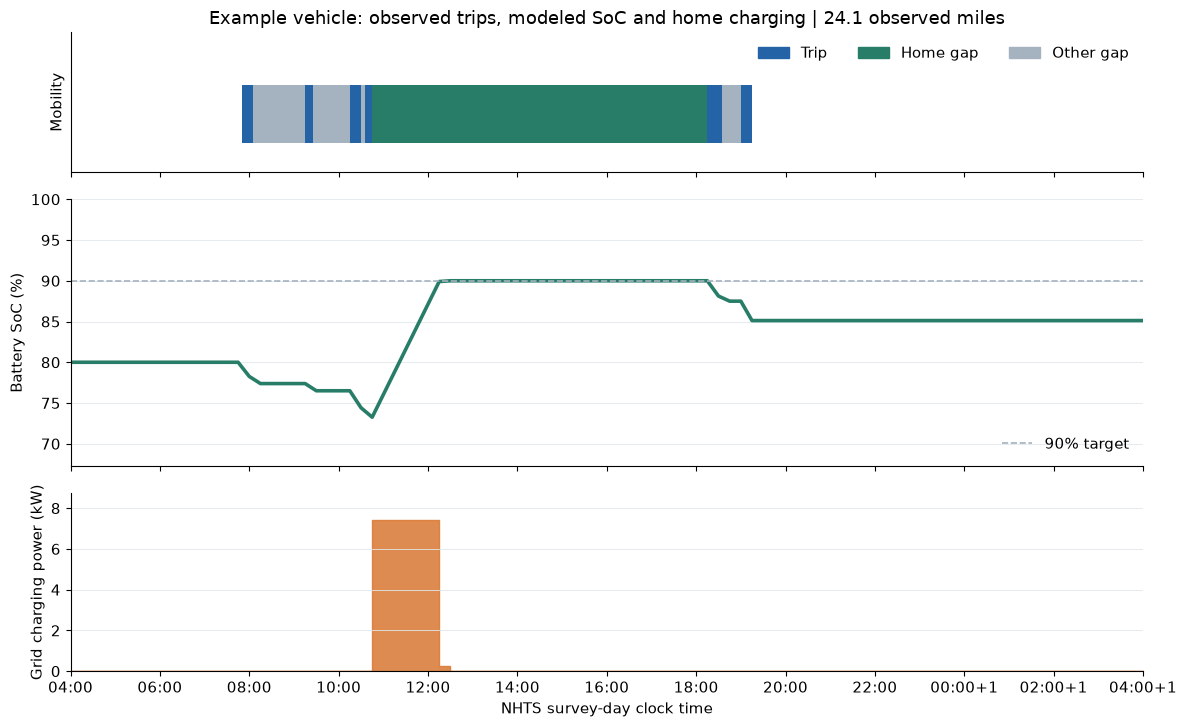

- The selected chain uses **7.0 kWh** for travel, then draws **11.2 kWh** from the grid during 1 observed internal Home gap(s).
- SoC decreases during blue trip spans and rises only while orange grid power is nonzero. No post-final Home duration is inserted.

In [6]:
plt.rcParams.update({"font.size":11,"axes.spines.top":False,
                     "axes.spines.right":False,"figure.facecolor":"white"})
BLUE, HOME, OTHER, POWER = "#2463a6", "#287d69", "#a5b2bf", "#d97732"
fig,axes=plt.subplots(3,1,figsize=(12,7.4),sharex=True,
                      gridspec_kw={"height_ratios":[1.1,2.1,1.4]})
for row in example.events.itertuples(index=False):
    color = BLUE if row.event_type=="trip" else HOME if row.location=="Home" else OTHER
    axes[0].broken_barh([(row.start_min,row.end_min-row.start_min)],(.25,.5),facecolors=color)
axes[0].set(yticks=[],ylabel="Mobility",title=(
    f"Example vehicle: observed trips, modeled SoC and home charging | "
    f"{example_miles:.1f} observed miles"))
axes[0].legend(handles=[Patch(color=BLUE,label="Trip"),Patch(color=HOME,label="Home gap"),
                        Patch(color=OTHER,label="Other gap")],ncol=3,
               frameon=False,loc="upper right")
axes[0].set_ylim(0,1.2)
axes[1].plot(SOC_TIMES_MIN,100*example.soc_fraction,color=HOME,lw=2.6)
axes[1].axhline(100*params.target_soc,color=OTHER,ls="--",lw=1.2,label="90% target")
axes[1].set(ylabel="Battery SoC (%)",ylim=(max(0,100*example.soc_fraction.min()-6),100))
axes[1].legend(frameon=False,loc="lower right")
power_x=np.r_[BIN_STARTS_MIN,DAY_END_MIN]
power_y=np.r_[example.power_kw,example.power_kw[-1]]
axes[2].fill_between(power_x,power_y,step="post",color=POWER,alpha=.85)
axes[2].set(ylabel="Grid charging power (kW)",xlabel="NHTS survey-day clock time",
            ylim=(0,params.home_charger_grid_kw*1.18))
ticks=np.arange(DAY_START_MIN,DAY_END_MIN+1,120)
labels=[clock(t) + ("+1" if t>=1440 else "") for t in ticks]
axes[2].set_xticks(ticks,labels)
axes[2].set_xlim(DAY_START_MIN,DAY_END_MIN)
for ax in axes[1:]: ax.grid(axis="y",color="#e1e6eb",lw=.6)
fig.tight_layout()
example_figure=figure_dir/"01_individual_trip_soc_charging.png"
fig.savefig(example_figure,dpi=190,bbox_inches="tight")
plt.show()
display(Markdown(
    f"- The selected chain uses **{drive_kwh:.1f} kWh** for travel, then draws "
    f"**{event_grid_kwh:.1f} kWh** from the grid during {len(charged_parks)} "
    "observed internal Home gap(s).\n"
    "- SoC decreases during blue trip spans and rises only while orange grid "
    "power is nonzero. No post-final Home duration is inserted."
))



## 6. Two aggregate scenarios on the same feasible sample

The observed-window scenario retains the original simulation exactly: charging
occurs only in directly reconstructable internal Home gaps. The synthetic
scenario adds one assumed terminal Home stay when the final trip ends at Home.
Its endpoint is the same vehicle-day's first departure time shifted forward
24 hours. Charging uses the same parameters and immediate Home rule. Charging
after next-day 04:00 is folded onto the matching clock bins of the 04:00–04:00
representative day. Neither curve is weighted or a national load forecast.


In [7]:
feasible_results=[]
failed=[]
for vehicle_id in clean_vehicle.index:
    result=simulate_vehicle(leg_groups[vehicle_id],gap_groups[vehicle_id],params)
    if result.feasible:
        feasible_results.append(result)
    else:
        failed.append((vehicle_id,result.failure_reason))
assert feasible_results
power_matrix=np.stack([result.power_kw for result in feasible_results])
aggregate_power_kw=power_matrix.sum(axis=0)
peak_bin=int(np.argmax(aggregate_power_kw))
peak_kw=float(aggregate_power_kw[peak_bin])
simulated_vehicles=len(feasible_results)
charging_at_peak=int(np.count_nonzero(power_matrix[:,peak_bin]>1e-9))
ever_charged=int(np.count_nonzero(power_matrix.sum(axis=1)>1e-9))
aggregate_grid_kwh=float(aggregate_power_kw.sum()*BIN_MIN/60)
event_grid_total=sum(result.grid_energy_kwh for result in feasible_results)
assert np.isclose(aggregate_grid_kwh,event_grid_total,atol=1e-6)
assert power_matrix.min()>=-1e-9 and power_matrix.max()<=params.home_charger_grid_kw+1e-9
failure_reasons=pd.Series([reason.split(": ",1)[-1] for _,reason in failed]).value_counts()
display(pd.Series({
    "clean input vehicle-days":len(clean_vehicle),
    "physically feasible simulated vehicles":simulated_vehicles,
    "flagged infeasible vehicle-days":len(failed),
    "peak sample demand (kW)":peak_kw,
    "peak bin starts":clock(BIN_STARTS_MIN[peak_bin])+("+1" if BIN_STARTS_MIN[peak_bin]>=1440 else ""),
    "normalized peak (kW/vehicle)":peak_kw/simulated_vehicles,
    "vehicles charging in peak 15-min bin":charging_at_peak,
    "share with charging in peak bin (%)":100*charging_at_peak/simulated_vehicles,
    "total grid charging energy (kWh)":aggregate_grid_kwh,
    "vehicles with any observed internal Home charge":ever_charged,
    "fraction of feasible vehicles that charge (%)":100*ever_charged/simulated_vehicles,
},name="Sample simulation"))
display(failure_reasons.rename("flagged vehicle-days").to_frame())



clean input vehicle-days                                   6225
physically feasible simulated vehicles                     6136
flagged infeasible vehicle-days                              89
peak sample demand (kW)                             1240.762347
peak bin starts                                           12:45
normalized peak (kW/vehicle)                            0.20221
vehicles charging in peak 15-min bin                        182
share with charging in peak bin (%)                    2.966102
total grid charging energy (kWh)                   10767.906039
vehicles with any observed internal Home charge            1118
fraction of feasible vehicles that charge (%)         18.220339
Name: Sample simulation, dtype: object

,flagged vehicle-days
trip energy exceeds available battery energy,86
positive distance with zero travel time,3


In [8]:
overnight_results = [reconstruct_terminal_home_charge(
    leg_groups[result.vehicle_id], result, params) for result in feasible_results]
synthetic_power_matrix = power_matrix + np.stack([r.power_kw for r in overnight_results])
synthetic_aggregate_power_kw = synthetic_power_matrix.sum(axis=0)
assert np.all(synthetic_power_matrix >= -1e-9)
assert np.all(synthetic_power_matrix <= params.home_charger_grid_kw + 1e-9)
assert np.allclose(synthetic_aggregate_power_kw - aggregate_power_kw,
                   np.stack([r.power_kw for r in overnight_results]).sum(axis=0))
assert np.isclose(synthetic_aggregate_power_kw.sum()*BIN_MIN/60,
                  aggregate_grid_kwh + sum(r.grid_energy_kwh for r in overnight_results))

def scenario_metrics(matrix, aggregate):
    peak = int(np.argmax(aggregate))
    charged = int(np.count_nonzero(matrix.sum(axis=1) > 1e-9))
    at_peak = int(np.count_nonzero(matrix[:,peak] > 1e-9))
    return {
        "Feasible vehicle-days": len(matrix),
        "Fraction charging (%)": 100*charged/len(matrix),
        "Total grid energy (kWh)": aggregate.sum()*BIN_MIN/60,
        "Aggregate peak (kW)": aggregate[peak],
        "Peak time": f"{clock(BIN_STARTS_MIN[peak])}–{clock(BIN_STARTS_MIN[peak]+BIN_MIN)}",
        "Normalized peak (kW/vehicle)": aggregate[peak]/len(matrix),
        "Charging at peak (vehicles)": at_peak,
        "Charging at peak (%)": 100*at_peak/len(matrix),
    }

scenario_table = pd.DataFrame({
    "Observed window only": scenario_metrics(power_matrix, aggregate_power_kw),
    "Synthetic overnight": scenario_metrics(synthetic_power_matrix, synthetic_aggregate_power_kw),
}).T
assert scenario_table["Feasible vehicle-days"].nunique() == 1
display(scenario_table)
display(pd.Series({
    "vehicle-days with terminal Home arrival": sum(r.arrival_min is not None for r in overnight_results),
    "vehicle-days with synthetic terminal charge": sum(r.grid_energy_kwh > 1e-9 for r in overnight_results),
    "synthetic terminal grid energy (kWh)": sum(r.grid_energy_kwh for r in overnight_results),
}, name="Synthetic interval audit"))


,Feasible vehicle-days,Fraction charging (%),Total grid energy (kWh),Aggregate peak (kW),Peak time,Normalized peak (kW/vehicle),Charging at peak (vehicles),Charging at peak (%)
Observed window only,6136,18.220339,10767.906039,1240.762347,12:45–13:00,0.20221,182,2.966102
Synthetic overnight,6136,96.267927,86606.007731,10138.099033,18:00–18:15,1.652233,1506,24.543677


vehicle-days with terminal Home arrival         5814.000000
vehicle-days with synthetic terminal charge     5814.000000
synthetic terminal grid energy (kWh)           75838.101692
Name: Synthetic interval audit, dtype: float64

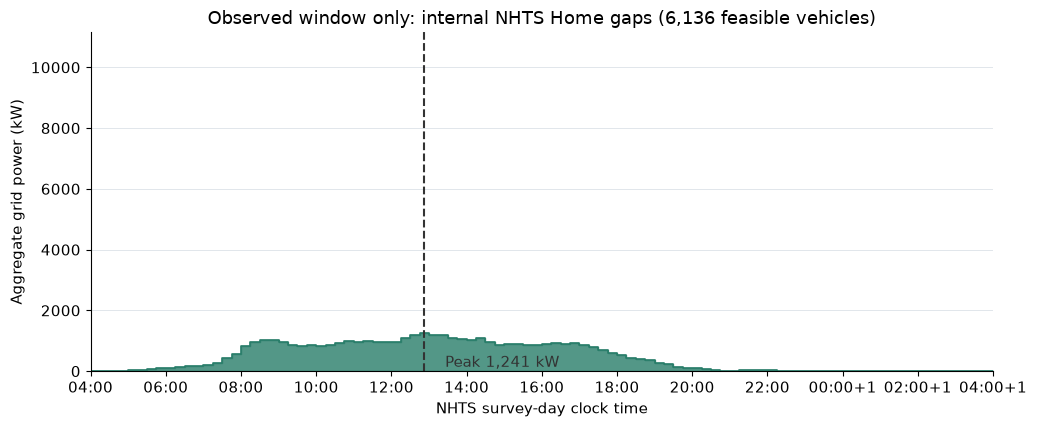

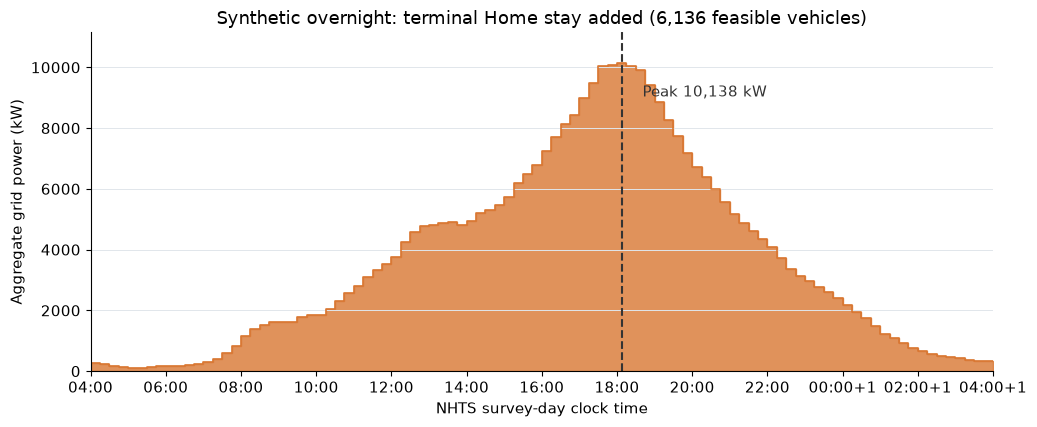

The synthetic reconstruction adds **75,838.1 kWh** (704.3% over observed-window charging). Its sample peak is **10,138 kW** at **18:00–18:15**, a change of **+8,897 kW** from the observed-window peak at **12:45–13:00**. The added terminal interval and next-day departure are assumptions, not observed parking.

In [9]:
common_ymax = 1.10 * max(aggregate_power_kw.max(), synthetic_aggregate_power_kw.max())
aggregate_x = np.r_[BIN_STARTS_MIN, DAY_END_MIN]
scenario_figures = [
    ("Observed window only: internal NHTS Home gaps", aggregate_power_kw,
     "02_aggregate_home_charging_sample.png", HOME),
    ("Synthetic overnight: terminal Home stay added", synthetic_aggregate_power_kw,
     "03_aggregate_home_charging_synthetic_overnight.png", POWER),
]
for title, profile, filename, color in scenario_figures:
    peak_bin_s = int(np.argmax(profile))
    peak_kw_s = float(profile[peak_bin_s])
    fig, ax = plt.subplots(figsize=(10.5, 4.4))
    aggregate_y = np.r_[profile, profile[-1]]
    ax.fill_between(aggregate_x, aggregate_y, step="post", color=color, alpha=.80)
    ax.plot(aggregate_x, aggregate_y, drawstyle="steps-post", color=color, lw=1.2)
    ax.axvline(BIN_STARTS_MIN[peak_bin_s]+BIN_MIN/2, color="#333333", ls="--", lw=1.5)
    ax.annotate(f"Peak {peak_kw_s:,.0f} kW",
                (BIN_STARTS_MIN[peak_bin_s]+BIN_MIN/2, peak_kw_s),
                xytext=(15,-24), textcoords="offset points", color="#333333")
    ax.set_xticks(ticks, labels)
    ax.set_xlim(DAY_START_MIN, DAY_END_MIN)
    ax.set_ylim(0, common_ymax)
    ax.set(title=f"{title} ({simulated_vehicles:,} feasible vehicles)",
           xlabel="NHTS survey-day clock time", ylabel="Aggregate grid power (kW)")
    ax.grid(axis="y", color="#e1e6eb", lw=.7)
    fig.tight_layout()
    fig.savefig(figure_dir/filename, dpi=190, bbox_inches="tight")
    plt.show()
aggregate_figure = figure_dir / scenario_figures[0][2]
synthetic_figure = figure_dir / scenario_figures[1][2]
energy_increase = scenario_table.loc["Synthetic overnight","Total grid energy (kWh)"] - aggregate_grid_kwh
peak_change = scenario_table.loc["Synthetic overnight","Aggregate peak (kW)"] - peak_kw
display(Markdown(
    f"The synthetic reconstruction adds **{energy_increase:,.1f} kWh** "
    f"({100*energy_increase/aggregate_grid_kwh:.1f}% over observed-window charging). "
    f"Its sample peak is **{scenario_table.loc['Synthetic overnight','Aggregate peak (kW)']:,.0f} kW** "
    f"at **{scenario_table.loc['Synthetic overnight','Peak time']}**, "
    f"a change of **{peak_change:+,.0f} kW** from the observed-window peak at "
    f"**{scenario_table.loc['Observed window only','Peak time']}**. "
    "The added terminal interval and next-day departure are assumptions, not observed parking."
))


## 7. Reality check and limits

The earlier Norway **residential** analysis found approximately 9 kWh median
delivered session energy, 12.7 kWh mean, 11.2 h median connection, and many
evening plug-ins. Those observations are separate from NHTS and do not calibrate
these rules. The observed-window curve omits terminal Home parking; the
synthetic curve assumes it lasts until the same vehicle-day's first-departure
clock time on the following day. This is a scenario, not measured dwell time,
next-day travel, or a fitted forecast.

**Key limitations:** NHTS chains are candidate person-reported vehicle days;
purpose continuity is not geographic proof; Home charging access is assumed;
initial SoC, charger rating and consumption are synthetic; energy consumption
is constant per km; all feasible vehicles use the same battery; and no
workplace or public charging is represented. The synthetic overnight interval
may be wrong for any individual vehicle and is folded onto a representative
24-hour clock for comparison.


In [10]:
print(f"ASSUMPTIONS: {params.battery_capacity_kwh:.0f} kWh battery, "
      f"{params.energy_consumption_kwh_per_km:.2f} kWh/km, "
      f"{params.home_charger_grid_kw:.1f} kW Home grid charger, "
      f"{100*params.charging_efficiency:.0f}% efficiency, "
      f"{100*params.initial_soc:.0f}% initial / {100*params.target_soc:.0f}% target SoC")
print(f"EXAMPLE {example.vehicle_id}: {example_miles:.1f} observed miles, "
      f"{drive_kwh:.2f} kWh driving, {event_grid_kwh:.2f} kWh grid charging, "
      f"final SoC {100*example.soc_fraction[-1]:.1f}%")
print(f"OBSERVED-WINDOW AGGREGATE: {simulated_vehicles:,} feasible vehicles; {len(failed)} flagged; "
      f"peak {peak_kw:,.1f} kW at {clock(BIN_STARTS_MIN[peak_bin])}; "
      f"{peak_kw/simulated_vehicles:.3f} kW/vehicle; "
      f"{100*charging_at_peak/simulated_vehicles:.1f}% charge in peak bin; "
      f"{aggregate_grid_kwh:,.1f} kWh grid energy; "
      f"{100*ever_charged/simulated_vehicles:.1f}% ever charge")
print("SYNTHETIC OVERNIGHT AGGREGATE:")
print(scenario_table.loc["Synthetic overnight"].to_string())
print("FIGURES:")
for path in [example_figure,aggregate_figure,synthetic_figure]: print(" -",path.relative_to(root).as_posix())


ASSUMPTIONS: 60 kWh battery, 0.18 kWh/km, 7.4 kW Home grid charger, 90% efficiency, 80% initial / 90% target SoC
EXAMPLE 900004819701: 24.1 observed miles, 6.98 kWh driving, 11.16 kWh grid charging, final SoC 85.1%
OBSERVED-WINDOW AGGREGATE: 6,136 feasible vehicles; 89 flagged; peak 1,240.8 kW at 12:45; 0.202 kW/vehicle; 3.0% charge in peak bin; 10,767.9 kWh grid energy; 18.2% ever charge
SYNTHETIC OVERNIGHT AGGREGATE:
Feasible vehicle-days                   6136
Fraction charging (%)              96.267927
Total grid energy (kWh)         86606.007731
Aggregate peak (kW)             10138.099033
Peak time                        18:00–18:15
Normalized peak (kW/vehicle)        1.652233
Charging at peak (vehicles)             1506
Charging at peak (%)               24.543677
FIGURES:
 - outputs/figures/ev_load_prototype/01_individual_trip_soc_charging.png
 - outputs/figures/ev_load_prototype/02_aggregate_home_charging_sample.png
 - outputs/figures/ev_load_prototype/03_aggregate_home_charg